# Residual Connections

[Kaiming He et al., "Deep residual layer fr image recognition", CVPR 2016](https://openaccess.thecvf.com/content_cvpr_2016/html/He_Deep_Residual_Learning_CVPR_2016_paper.html)

Given a mapping  $g : \mathbb{R}^d \to \mathbb{R}^d$, a residual connection is defined as
$$
f(x) = x + g(x).
$$

## Gradient does not vanishes

Let $f(w)=g_2(ag_1(w)+b)$ and $f_r(w)=g_1(w)+g_2(ag_1(w)+b)$.
$$
\begin{align*}
\frac{\partial f(w)}{\partial w}&=ag'_2(ag_1(w)+b)g'_1(w),\\
\frac{\partial f_r(w)}{\partial w}&=ag'_2(ag_1(w)+b)g'_1(w)+g_1'(w)=(\underbrace{ag'_2(ag_1(w)+b)+1}_{\approx 1})g'_1(w)
\end{align*}
$$

## Definition

Input
* $x \in \mathbb{R}^{d_{in}}$ 

Weights
* weight $W \in \mathbb{R}^{d_{out}\times d_{in}}$ 
* bias $b \in \mathbb{R}^{d_{out}}$

Output
* $o \in \mathbb{R}^{d_{out}}$

$$o = \text{ResConn}_{f}(x)=f(x)+\begin{cases}x,& \text{if } d_{in}=d_{out}\\
\operatorname{Linear}_{W,b}(x),& \text{if } d_{in}\neq d_{out}\\
\end{cases}.$$

where $f:\mathbb{R}^{d_{in}} \mapsto \mathbb{R}^{d_{out}}$ is the "skipped block".

## Code

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from torch.utils.data import DataLoader

import models.deep_learning.components as mynn
from helpers import get_device

In [2]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        activation: nn.Module | None = None,
        res_connect: bool = False,
    ):
        super().__init__()  # type: ignore
        if activation is None:
            activation = nn.ReLU()

        layers: list[nn.Module] = [nn.Flatten()]
        in_dim = input_dim
        for h_dim in hidden_dims:
            block = nn.Sequential(
                nn.Linear(in_dim, h_dim), nn.LayerNorm(h_dim), activation
            )
            if res_connect:
                layers.append(mynn.ResidualConnection(block, in_dim, h_dim))
            else:
                layers.append(block)
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_dim, bias=False))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

## Testing

Compare with no skip conneciton

In [3]:
device = get_device()

### Create Dataset

In [4]:
size = (128, 128)
transform = torchvision.transforms.Compose(
    [torchvision.transforms.Resize(size), torchvision.transforms.ToTensor()]
)
train_dataset = torchvision.datasets.Flowers102(
    root="../raw_data", split="train", download=True, transform=transform
)
test_dataset = torchvision.datasets.Flowers102(
    root="../raw_data", split="test", download=True, transform=transform
)

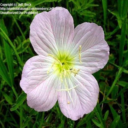

In [5]:
def visualize_image(img: torch.Tensor) -> Image.Image:
    return Image.fromarray((img.permute(1, 2, 0) * 255).to(torch.uint8).numpy())


visualize_image(train_dataset[1][0])

In [6]:
lr = 0.001
momentum = 0.9
batch_size = 32
loss = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)  # type: ignore
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)  # type: ignore

### Train

#### MLP

In [7]:
torch.manual_seed(1)  # type: ignore

mlp = MLP(
    input_dim=size[0] * size[1] * 3, hidden_dims=[512, 512, 512], output_dim=102
).to(device)


optimizer = torch.optim.SGD(mlp.parameters(), lr=lr, momentum=momentum)

mlp.train()
losses: list[float] = []
for epoch in range(30):
    for img, label in train_loader:
        img = img.to(device)
        label = label.to(device)
        pred_y = mlp(img)
        optimizer.zero_grad()
        loss_value = loss(pred_y, label)
        loss_value.backward()
        optimizer.step()  # type: ignore
        losses.append(loss_value.item())
    if epoch % 1 == 0:
        print(f"Epoch {epoch}, loss: {sum(losses) / len(losses)}")

Epoch 0, loss: 4.7051501125097275
Epoch 1, loss: 4.652521051466465
Epoch 2, loss: 4.583967909216881
Epoch 3, loss: 4.497884977608919
Epoch 4, loss: 4.407950419187546
Epoch 5, loss: 4.314936892439921
Epoch 6, loss: 4.221746983272689
Epoch 7, loss: 4.131229049526155
Epoch 8, loss: 4.039383727643225
Epoch 9, loss: 3.9476291336119176
Epoch 10, loss: 3.854744344272397
Epoch 11, loss: 3.7603436379383006
Epoch 12, loss: 3.6669353304001002
Epoch 13, loss: 3.57554913099323
Epoch 14, loss: 3.485198350995779
Epoch 15, loss: 3.389180507976562
Epoch 16, loss: 3.296862290843445
Epoch 17, loss: 3.2046245233052306
Epoch 18, loss: 3.1119715238088057
Epoch 19, loss: 3.021321856603026
Epoch 20, loss: 2.9312112258658525
Epoch 21, loss: 2.8425069713795725
Epoch 22, loss: 2.7562926127372878
Epoch 23, loss: 2.670471386440719
Epoch 24, loss: 2.5887966841086745
Epoch 25, loss: 2.5075331549518385
Epoch 26, loss: 2.429327231693875
Epoch 27, loss: 2.3539805265110254
Epoch 28, loss: 2.2815630598925054
Epoch 29, lo

In [8]:
torch.manual_seed(1)  # type: ignore

skipmlp = MLP(
    input_dim=size[0] * size[1] * 3,
    hidden_dims=[512, 512, 512],
    output_dim=102,
    res_connect=True,
).to(device)


optimizer = torch.optim.SGD(skipmlp.parameters(), lr=lr, momentum=momentum)

skipmlp.train()
skip_losses: list[float] = []
for epoch in range(30):
    for img, label in train_loader:
        img = img.to(device)
        label = label.to(device)
        pred_y = skipmlp(img)
        optimizer.zero_grad()
        loss_value = loss(pred_y, label)
        loss_value.backward()
        optimizer.step()  # type: ignore
        skip_losses.append(loss_value.item())
    if epoch % 1 == 0:
        print(f"Epoch {epoch}, loss: {sum(skip_losses) / len(skip_losses)}")

Epoch 0, loss: 4.861629918217659
Epoch 1, loss: 4.5104284174740314
Epoch 2, loss: 4.173065175612767
Epoch 3, loss: 3.8792693484574556
Epoch 4, loss: 3.6197221755981444
Epoch 5, loss: 3.380265592907866
Epoch 6, loss: 3.1717204009847983
Epoch 7, loss: 2.979188488330692
Epoch 8, loss: 2.789081368388401
Epoch 9, loss: 2.6130804914981125
Epoch 10, loss: 2.45283925448629
Epoch 11, loss: 2.3046129965999476
Epoch 12, loss: 2.1664340309082317
Epoch 13, loss: 2.037349719188309
Epoch 14, loss: 1.9206407585802177
Epoch 15, loss: 1.8124295466695912
Epoch 16, loss: 1.7140014809282387
Epoch 17, loss: 1.624141399205352
Epoch 18, loss: 1.5423245661168996
Epoch 19, loss: 1.4676942828693427
Epoch 20, loss: 1.399593812463406
Epoch 21, loss: 1.3374281375647776
Epoch 22, loss: 1.2804569700231736
Epoch 23, loss: 1.2280911434669786
Epoch 24, loss: 1.1798195031029173
Epoch 25, loss: 1.1351805107618789
Epoch 26, loss: 1.0937793459560015
Epoch 27, loss: 1.0552904281576048
Epoch 28, loss: 1.0194095143815503
Epoch

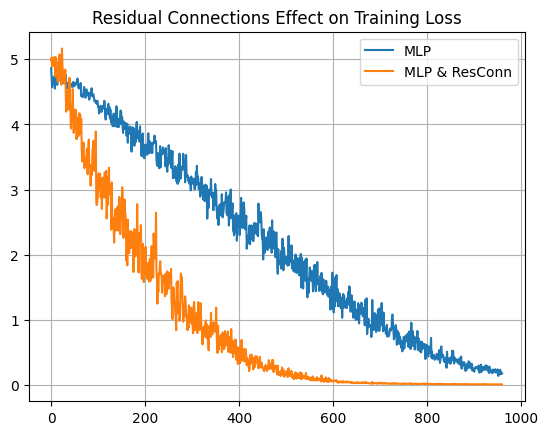

In [9]:
plt.plot(losses, linestyle="-", label="MLP")
plt.plot(skip_losses, linestyle="-", label="MLP & ResConn")
plt.title("Residual Connections Effect on Training Loss")
plt.grid(True)
plt.legend()
plt.show()

### Evaluation

In [10]:
accuracy: float | None = None
for test_images, test_labels in test_loader:
    test_images, test_labels = test_images.to(device), test_labels.to(device)
    pred_test = mlp(test_images)
    accuracy = ((pred_test.argmax(dim=1) == test_labels).float().mean()).item()
print(f"Test accuracy: {accuracy}")

Test accuracy: 0.14945518970489502


In [11]:
for test_images, test_labels in test_loader:
    test_images, test_labels = test_images.to(device), test_labels.to(device)
    prred_test = skipmlp(test_images)
    accuracy = ((prred_test.argmax(dim=1) == test_labels).float().mean()).item()
print(f"Test accuracy: {accuracy}")

Test accuracy: 0.1544966697692871
